In [71]:

import numpy as np
import os, glob


# scientific libraries
from scipy.ndimage import center_of_mass as nd_center_of_mass
from scipy.ndimage import gaussian_filter, shift, map_coordinates, fourier_shift
from skimage.registration import phase_cross_correlation
from applefy.utils.positions import center_subpixel
from scipy.optimize import curve_fit


from utils.statistics import *

# images
import matplotlib as mpl
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
mpl.rcParams["hatch.linewidth"] = 0.5  # previous pdf hatch linewidth
import tifffile as tiff
from matplotlib.patches import Circle
from photutils.aperture import CircularAperture
from photutils.aperture import CircularAnnulus


In [106]:
ori_folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/'


#geometry
radius = 55
mask_radius = 35
mask_outlier = CircularAperture((radius, radius), mask_radius).to_mask(method = 'center')
DIT_psf = 29e-6
DIT_img = 10e-3


# Get all files
files = sorted(glob.glob(f"{ori_folder}*.tif"))

# Separate correctly
img_files = [
    f for f in files
    if "coro" in os.path.basename(f)
    and "no_coro" not in os.path.basename(f)
]

psf_files = [
    f for f in files
    if "no_coro" in os.path.basename(f)
]

img_files


['/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_10ro_10ws_coro_2026-08-25T11-59-58.572_0.tif',
 '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_10ro_10ws_coro_2026-08-25T12-02-26.76_0.tif',
 '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_10ro_15ws_coro_2026-08-25T12-11-56.909_0.tif',
 '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_10ro_15ws_coro_2026-08-25T12-13-40.756_0.tif',
 '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_10ro_20ws_coro_2026-08-25T12-22-48.526_0.tif',
 '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_10ro_20ws_coro_2026-08-25T12-24-31.861_0.tif',
 '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_5ro_10ws_coro_2026-08-25T10-45-28.654_0.tif',
 '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_5ro_10ws_coro_2026-08-25T10-47-14.332_0.tif',
 '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_5ro_15ws_coro_2026-08-25T10-57-42

# Correlation Matrix

In [107]:
img_file = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_24/int_5ro_10ws_coro_2026-08-25T10-45-2'

key = 9986
sci_img = tiff.imread(glob.glob(f"{img_file}*.tif"), 
                        key=slice(0,key) 
                        )
sci_img.shape

(9984, 200, 200)

In [12]:
def temporal_correlation(stack, sub = None):
    results = {}
    
    if sub == 'median':
        stack = stack - np.median(stack, axis = 0)
    if sub == 'mean':
        stack = stack - np.mean(stack, axis = 0)

    X = np.asarray(stack).reshape(len(stack), -1)

    correlation_matrix = np.full((len(X), len(X)), np.nan)

    corr = np.corrcoef(X)

    i, j = np.triu_indices(len(X), k=1)
    correlation_matrix[i, j] = corr[i, j]
    corr_values = correlation_matrix[~np.isnan(correlation_matrix)]
    median_corr = np.median(corr_values)

    results['correlation_matrix'] = correlation_matrix
    results['correlation_median'] = median_corr


    #1 D
    side = correlation_matrix.shape[0]

    correlation_1d_med = np.array([
        np.nanmedian(np.diagonal(correlation_matrix, offset=d))
        for d in range(1, side)
    ])

    correlation_1d = np.array([
        np.nanmean(np.diagonal(correlation_matrix, offset=d))
        for d in range(1, side)
    ])

    results['correlation_1d_median'] = correlation_1d_med
    results['correlation_1d_mean'] = correlation_1d

    return results



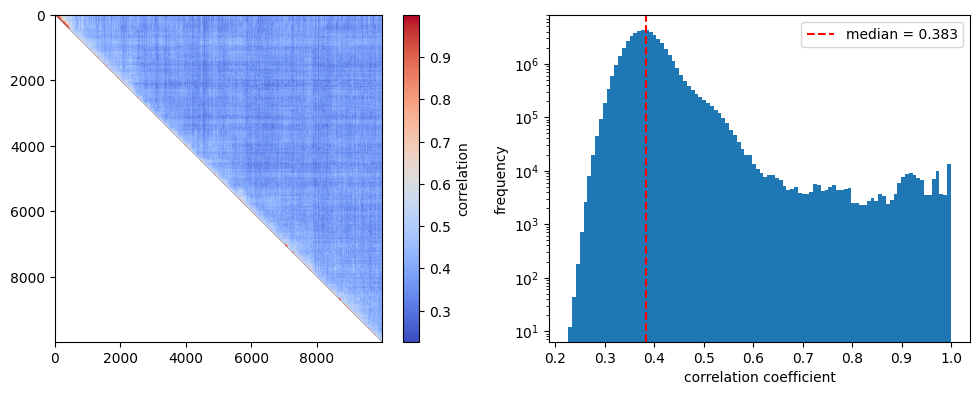

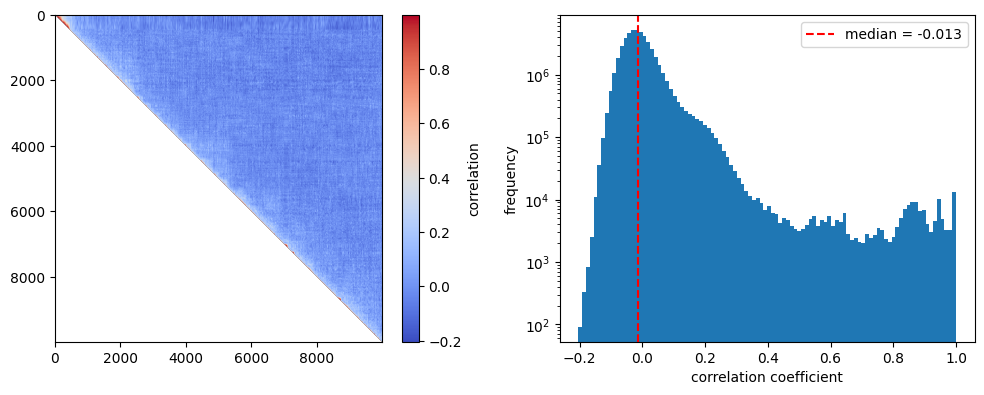

In [13]:
results = temporal_correlation(sci_img)
correlation_matrix = results['correlation_matrix']
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.imshow(correlation_matrix, cmap='coolwarm')
plt.colorbar(label='correlation')

plt.subplot(122)
corr_values = correlation_matrix[~np.isnan(correlation_matrix)]

plt.hist(corr_values, bins=100)
plt.xlabel('correlation coefficient')
plt.ylabel('frequency')

median_corr = np.median(corr_values)
plt.axvline(median_corr, color='red', linestyle='--',
            label=f'median = {median_corr:.3f}')
plt.yscale('log')
plt.legend()

plt.tight_layout()

results = temporal_correlation(sci_img, sub='mean')
correlation_matrix = results['correlation_matrix']
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.imshow(correlation_matrix, cmap='coolwarm')
plt.colorbar(label='correlation')

plt.subplot(122)
corr_values = correlation_matrix[~np.isnan(correlation_matrix)]

plt.hist(corr_values, bins=100)
plt.xlabel('correlation coefficient')
plt.ylabel('frequency')

median_corr = np.median(corr_values)
plt.axvline(median_corr, color='red', linestyle='--',
            label=f'median = {median_corr:.3f}')
plt.yscale('log')
plt.legend()

plt.tight_layout()


Text(0, 0.5, 'Median correlation coefficient')

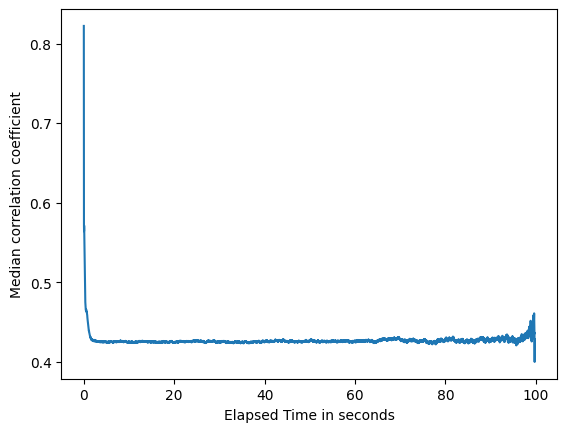

In [10]:
side = correlation_matrix.shape[0]

correlation_1d_med = np.array([
    np.nanmedian(np.diagonal(correlation_matrix, offset=d))
    for d in range(1, side)
])

correlation_1d = np.array([
    np.nanmean(np.diagonal(correlation_matrix, offset=d))
    for d in range(1, side)
])

DIT = 10e-3

plt.plot(np.arange(1, side) * DIT, correlation_1d_med)
plt.xlabel(r'Elapsed Time in seconds')
plt.ylabel('Median correlation coefficient')


# Regions and Masks

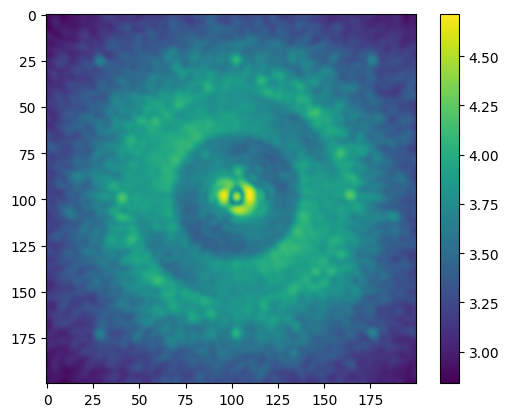

In [15]:
mean = np.mean(sci_img, axis = 0)
plt.imshow(np.log10(mean))
plt.colorbar()

Text(0.5, 1.0, 'Uncontrolled Radius Mask')

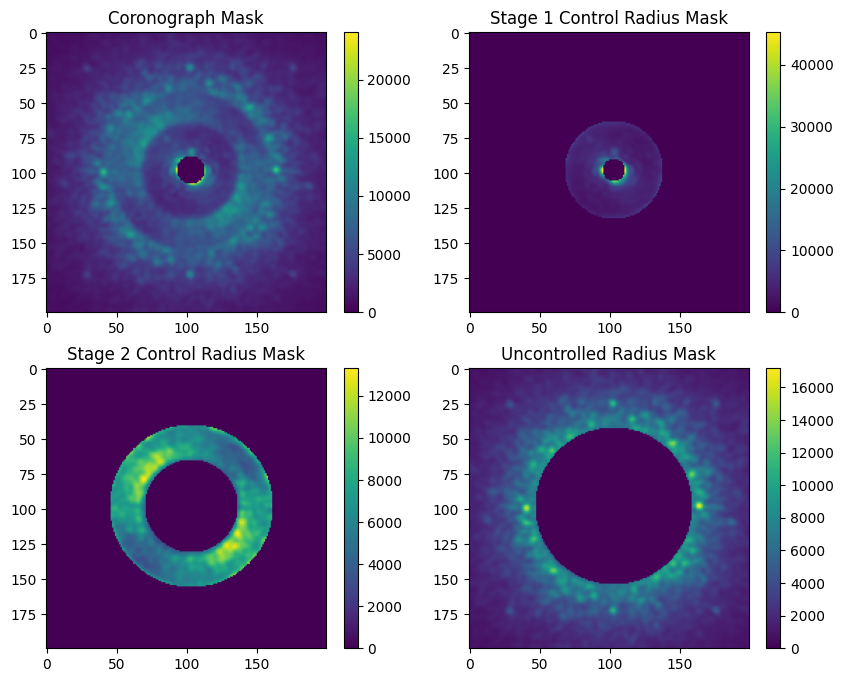

In [42]:
center =( 103, 98)
edge_coro = 10
edge_stg1 = 35
edge_stg2 = 58
edge_atm = 160
coro = CircularAperture(center, edge_coro).to_mask('center').to_image(mean.shape)
coro_ = ~coro.astype(bool)
stg1 = CircularAnnulus(center, edge_coro -2 , edge_stg1).to_mask('center').to_image(mean.shape)
stg2 = CircularAnnulus(center, edge_stg1 - 2, edge_stg2).to_mask('center').to_image(mean.shape)
atm = CircularAnnulus(center, edge_stg2 -2, edge_atm).to_mask('center').to_image(mean.shape)

plt.figure(figsize = (10,8))
plt.subplot(221)
plt.imshow(mean*coro_)
plt.colorbar()
plt.title('Coronograph Mask')
plt.subplot(222)
plt.imshow(mean*stg1)
plt.colorbar()
plt.title('Stage 1 Control Radius Mask')
plt.subplot(223)
plt.imshow(mean*stg2)
plt.colorbar()
plt.title('Stage 2 Control Radius Mask')
plt.subplot(224)
plt.imshow(mean*atm)
plt.colorbar()
plt.title('Uncontrolled Radius Mask')

In [81]:
        # Exponential decay model
def exp_decay(d, A, xi, C0):
    return A * np.exp(-d / xi) + C0

In [102]:
def temporal_correlation(stack, masks=None, sub=None):
    results = {}

    stack = np.asarray(stack)

    if sub == 'median':
        stack = stack - np.median(stack, axis=0)
    elif sub == 'mean':
        stack = stack - np.mean(stack, axis=0)

    # No masks → full image
    if masks is None:
        masks = {'full': np.ones(stack.shape[1:], dtype=bool)}

    for name, mask_area in masks.items():
        # Extract only pixels in this region
        X = stack * mask_area
        X = X.reshape(len(stack), -1)

        correlation_matrix = np.full(
            (len(X), len(X)),
            np.nan
        )

        corr = np.corrcoef(X)

        i, j = np.triu_indices(len(X), k=1)
        correlation_matrix[i, j] = corr[i, j]

        corr_values = correlation_matrix[~np.isnan(correlation_matrix)]
        median_corr = np.median(corr_values)

        # 1D
        side = correlation_matrix.shape[0]

        correlation_1d_med = np.array([
            np.nanmedian(
                np.diagonal(correlation_matrix, offset=d)
            )
            for d in range(1, side)
        ])

        correlation_mean = np.array([
            np.nanmean(
                np.diagonal(correlation_matrix, offset=d)
            )
            for d in range(1, side)
        ])

        correlation_std = np.array([
            np.nanstd(np.diagonal(correlation_matrix, offset=d))
            for d in range(1, side)
        ])


        # Initial guess
        top = 100
        d = np.arange(1, top + 1)

        # Restrict to the first `top` distances, then keep only finite values
        mean = correlation_mean[:top]
        std = correlation_std[:top]

        mask = np.isfinite(mean) & np.isfinite(std)

        d_fit = d[mask]
        mean_fit = mean[mask]
        std_fit = std[mask]

        # Initial guess
        p0 = [
            mean_fit[0] - mean_fit[-1],  # amplitude
            top / 5,                     # decay length
            mean_fit[-1]                 # baseline
        ]

        # Fit
        params, covariance = curve_fit(
            exp_decay,
            d_fit,
            mean_fit,
            sigma=std_fit,
            absolute_sigma=True,
            p0=p0,
            maxfev=10000
        )


        param_std = np.sqrt(np.diag(covariance))


        results[name] = {
            'correlation_matrix': correlation_matrix,
            'correlation_median': median_corr,
            'correlation_1d_median': correlation_1d_med,
            'correlation_1d_mean': correlation_mean,
            'correlation_1d_std': correlation_std,
            'exp_fit_params': params,
            'exp_fit_std': param_std,
        }

    return results

In [103]:
center =( 103, 98)
edge_coro = 10
edge_stg1 = 35
edge_stg2 = 58
edge_atm = 160

masks = {
    'coro' : ~CircularAperture(center, edge_coro).to_mask(method = 'center').to_image(sci_img.shape[-2:]).astype(bool),
    'stage_1' : CircularAnnulus(center, edge_coro -2 , edge_stg1).to_mask(method ='center').to_image(sci_img.shape[-2:]),
    'stage_2' : CircularAnnulus(center, edge_stg1 - 2, edge_stg2).to_mask(method ='center').to_image(sci_img.shape[-2:]),
    'rest' : CircularAnnulus(center, edge_stg2 -2, edge_atm).to_mask(method ='center').to_image(sci_img.shape[-2:]),
}

results = temporal_correlation(sci_img, masks=masks, sub='mean')

In [88]:
results_df = pd.DataFrame(results)
results_df

,coro,stage_1,stage_2,rest
correlation_matrix,"[[nan, 0.7286164712151778, 0.46482089998469583...","[[nan, 0.5290618327491825, 0.32870518852118835...","[[nan, 0.5498538930273128, 0.26431570193366694...","[[nan, 0.8172279084033384, 0.5689921944784678,..."
correlation_median,-0.003508,-0.001082,-0.00334,-0.004554
correlation_1d_median,"[0.7263011913240534, 0.46699703426142175, 0.37...","[0.6595865238744013, 0.36093580471769887, 0.27...","[0.5434778628934155, 0.21681638284694377, 0.17...","[0.8075120722695655, 0.5735877242417404, 0.462..."
correlation_1d_mean,"[0.742722751428198, 0.4944488305404483, 0.4048...","[0.6628134450970059, 0.379355543155783, 0.2939...","[0.5688718354275702, 0.259102167421472, 0.2127...","[0.8186190826077221, 0.5945539197468742, 0.487..."
correlation_1d_std,"[0.0805080709769449, 0.13531723258796743, 0.15...","[0.12136554155977769, 0.19356863342097944, 0.2...","[0.1407035650192474, 0.1976437255093564, 0.199...","[0.06032545407117394, 0.11684924220803447, 0.1..."
exp_fit_params,"[0.6489707793291909, 1991.8, 0.09375197209900712]","[0.7595625097698999, 1991.8, -0.09674906467289...","[0.4993742224637794, 1991.8, 0.06949761296379087]","[0.6796773981170131, 1991.8, 0.138941684490709]"
exp_fit_std,"[inf, inf, inf]","[inf, inf, inf]","[inf, inf, inf]","[inf, inf, inf]"


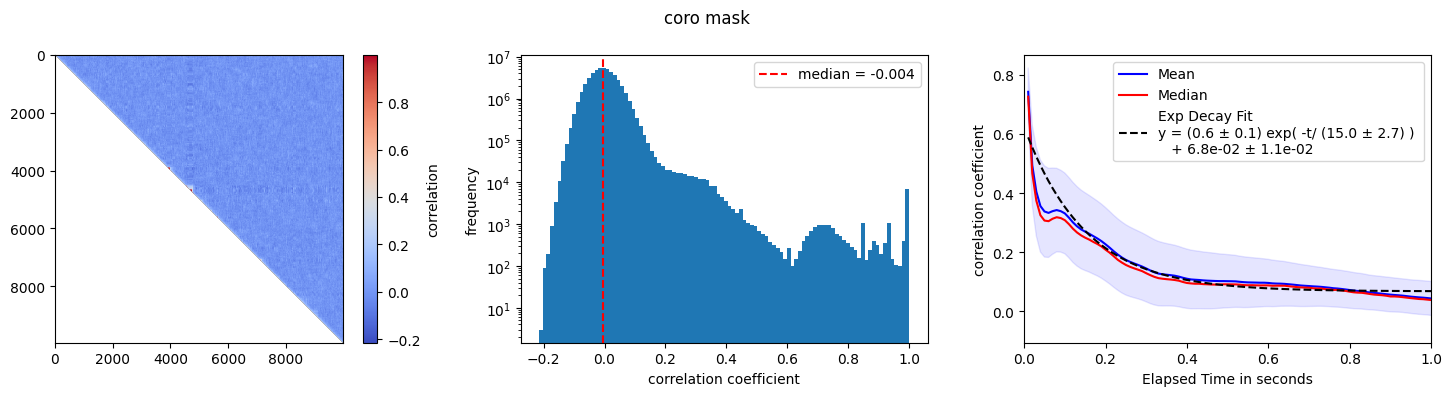

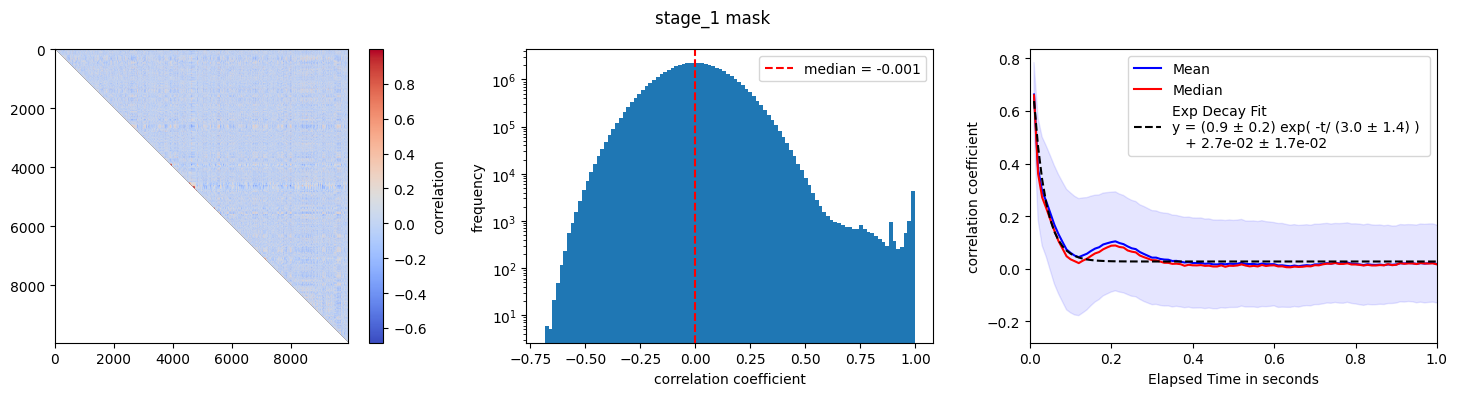

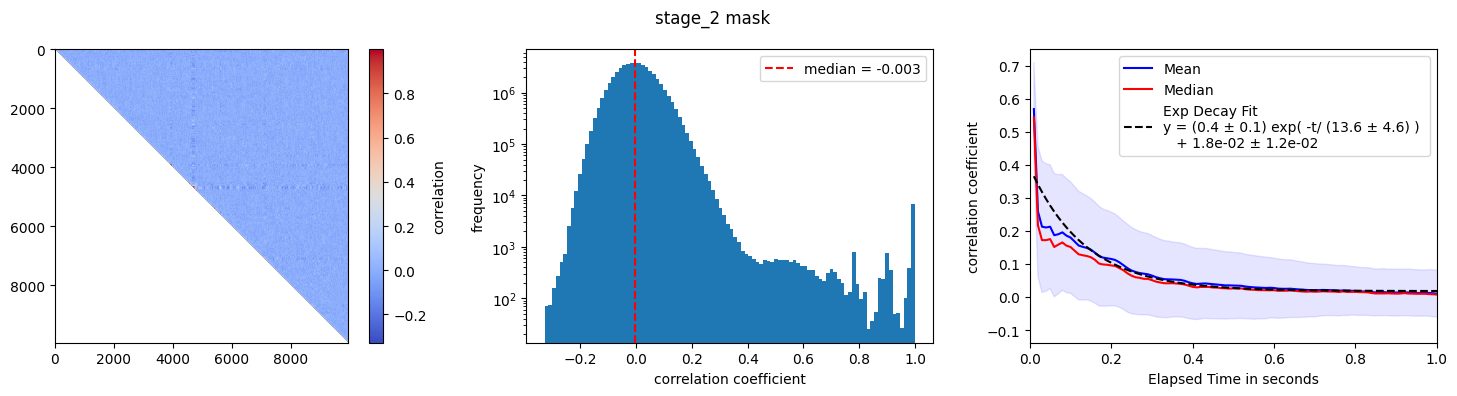

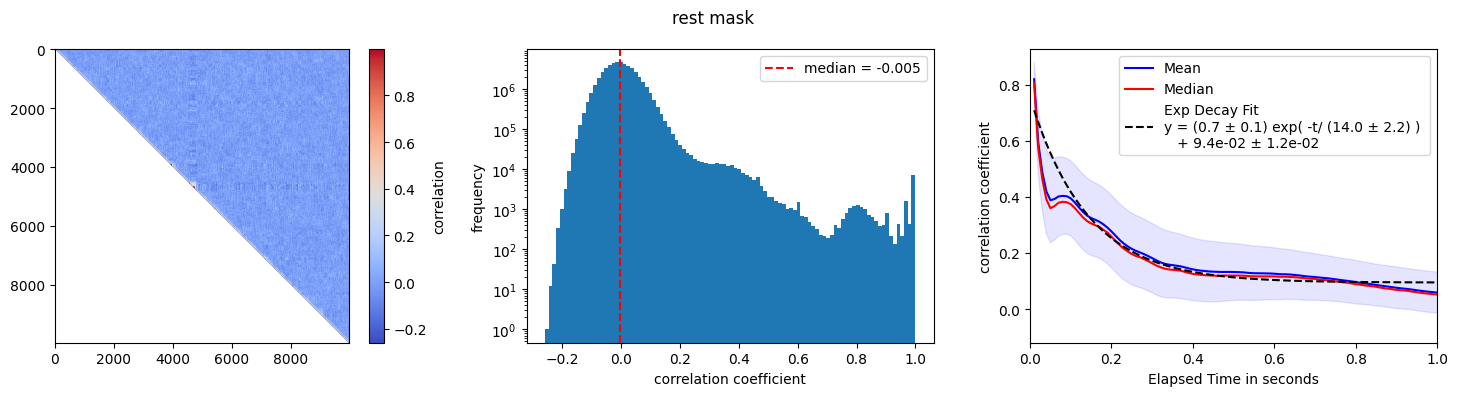

In [105]:
DIT = 10e-3

for col in results.keys():
    correlation_matrix = results[col]['correlation_matrix']
    plt.figure(figsize=(15, 4))
    plt.suptitle(col + ' mask')
    plt.subplot(131)
    plt.imshow(correlation_matrix, cmap='coolwarm')
    plt.colorbar(label='correlation')

    plt.subplot(132)
    corr_values = correlation_matrix[~np.isnan(correlation_matrix)]

    plt.hist(corr_values, bins=100)
    plt.xlabel('correlation coefficient')
    plt.ylabel('frequency')

    median_corr = np.median(corr_values)
    plt.axvline(median_corr, color='red', linestyle='--',
                label=f'median = {median_corr:.3f}')
    plt.yscale('log')
    plt.legend()

    plt.subplot(133)
    side = correlation_matrix.shape[0]
    d = np.arange(1, side) * DIT
    plt.plot(d, results[col]['correlation_1d_mean'], label = 'Mean', color = 'blue')
    plt.fill_between(d, results[col]['correlation_1d_mean'] - results[col]['correlation_1d_std'] , results[col]['correlation_1d_mean'] + results[col]['correlation_1d_std'], color = 'blue', alpha = 0.1)
    plt.plot(d, results[col]['correlation_1d_median'], label = 'Median', color = 'red')
    A, xi, C0 = results[col]['exp_fit_params']
    As, xis, C0s = results[col]['exp_fit_std']
    y_fit = exp_decay(d, A, xi * DIT, C0)
    plt.plot(d, y_fit, label = 'Exp Decay Fit' + f'\ny = ({A:.1f} ± {As:.1f}) exp( -t/ ({xi:.1f} ± {xis:.1f}) ) \n   + {C0:.1e} ± {C0s:.1e}', color = 'black', ls = '--')
    plt.xlabel(r'Elapsed Time in seconds')
    plt.ylabel('correlation coefficient')
    plt.xlim(0, 1)
    plt.legend()
    
    plt.tight_layout()